## Import Library

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib 
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

## Load & Eksplorasi Data

In [13]:
df = pd.read_csv('sayur_buah_clean_v3.csv')

print(df.shape)
df.head()

(4462, 6)


,nama_item,jenis_item,lokasi_penyimpanan,hari_sejak_pembelian,sisa_hari,label
0,Anggur,Buah,Pembeku,2,34.7,Mentah
1,Wortel,Sayur,Pendingin,1,25.2,Segar
2,Wortel,Sayur,Suhu Ruang,3,14.7,Segar
3,Pisang,Buah,Suhu Ruang,4,7.7,Mentah
4,Mangga,Buah,Suhu Ruang,1,8.8,Matang


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4462 entries, 0 to 4461
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   nama_item             4462 non-null   object 
 1   jenis_item            4462 non-null   object 
 2   lokasi_penyimpanan    4462 non-null   object 
 3   hari_sejak_pembelian  4462 non-null   int64  
 4   sisa_hari             4462 non-null   float64
 5   label                 4462 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 209.3+ KB


In [17]:
df.isnull().sum()

nama_item               0
jenis_item              0
lokasi_penyimpanan      0
hari_sejak_pembelian    0
sisa_hari               0
label                   0
dtype: int64

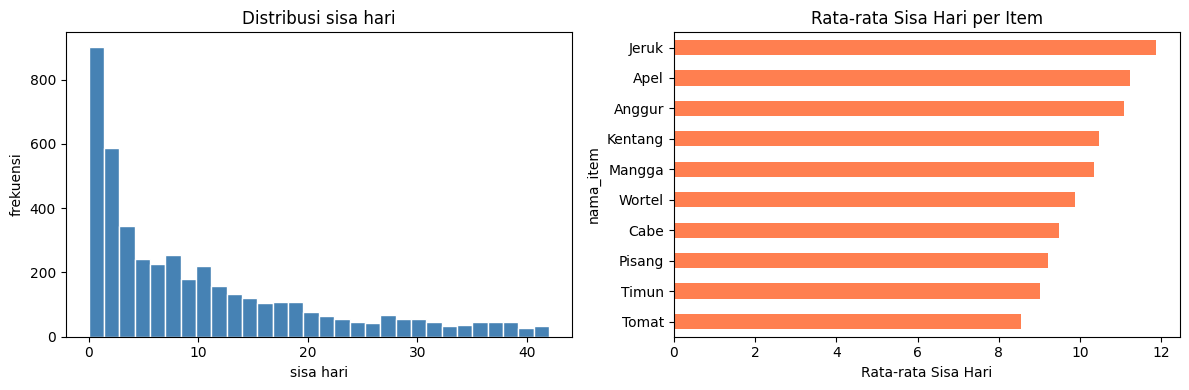

In [19]:
# Distribusi target

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['sisa_hari'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi sisa hari')
axes[0].set_xlabel('sisa hari')
axes[0].set_ylabel('frekuensi')

df.groupby('nama_item')['sisa_hari'].mean().sort_values().plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Rata-rata Sisa Hari per Item')
axes[1].set_xlabel('Rata-rata Sisa Hari')

plt.tight_layout()
plt.show()

## Preprocessing

In [24]:
CAT_COLS = ['nama_item', 'jenis_item', 'lokasi_penyimpanan', 'label']
NUM_COLS = ['hari_sejak_pembelian']
TARGET   = 'sisa_hari'

FEATURE_COLS = CAT_COLS + NUM_COLS

In [26]:
X = df[FEATURE_COLS].copy()
y = df[TARGET].values.astype(np.float32)

print('Fitur:', FEATURE_COLS)
print('Shape X:', X.shape, '| Shape y:', y.shape)

Fitur: ['nama_item', 'jenis_item', 'lokasi_penyimpanan', 'label', 'hari_sejak_pembelian']
Shape X: (4462, 5) | Shape y: (4462,)


In [28]:
encoders = {}

for col in CAT_COLS:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

nama_item: {'Anggur': 0, 'Apel': 1, 'Cabe': 2, 'Jeruk': 3, 'Kentang': 4, 'Mangga': 5, 'Pisang': 6, 'Timun': 7, 'Tomat': 8, 'Wortel': 9}
jenis_item: {'Buah': 0, 'Sayur': 1}
lokasi_penyimpanan: {'Pembeku': 0, 'Pendingin': 1, 'Suhu Ruang': 2}
label: {'Busuk': 0, 'Matang': 1, 'Mentah': 2, 'Segar': 3, 'Terlalu Matang': 4}


In [30]:
# Scaler
scaler = StandardScaler()
X[NUM_COLS] = scaler.fit_transform(X[NUM_COLS])

X_array = X.values.astype(np.float32)
print('Sample X setelah preprocessing:')
print(X_array[:3])

Sample X setelah preprocessing:
[[ 0.          0.          0.          2.          0.08667058]
 [ 9.          1.          1.          3.         -0.4931257 ]
 [ 9.          1.          2.          3.          0.6664669 ]]


In [32]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_array, y, test_size=0.30, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED
)

print(f'Train   : {X_train.shape[0]} sampel')
print(f'Val     : {X_val.shape[0]} sampel')
print(f'Test    : {X_test.shape[0]} sampel')

Train   : 3123 sampel
Val     : 669 sampel
Test    : 670 sampel


## Build Model

In [35]:
def build_model(input_dim: int, learning_rate: float = 1e-3) -> keras.Model:
    """
    MLP untuk regresi sisa hari.
    
    Arsitektur:
      - 3 hidden layer dengan ukuran bertahap mengecil
      - BatchNormalization: menstabilkan training
      - Dropout: mencegah overfitting (data ~4400 baris)
      - L2 regularization: tambahan pengaman overfitting
      - Output: 1 neuron linear (regresi, prediksi float)
    """
    inputs = keras.Input(shape=(input_dim,), name='input_fitur')

    # Layer 1
    x = layers.Dense(
        128,
        activation='relu',
        kernel_regularizer=regularizers.l2(1e-4),
        name='dense_1'
    )(inputs)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Dropout(0.3, name='drop_1')(x)

    # Layer 2
    x = layers.Dense(
        64,
        activation='relu',
        kernel_regularizer=regularizers.l2(1e-4),
        name='dense_2'
    )(x)
    x = layers.BatchNormalization(name='bn_2')(x)
    x = layers.Dropout(0.2, name='drop_2')(x)

    # Layer 3
    x = layers.Dense(
        32,
        activation='relu',
        kernel_regularizer=regularizers.l2(1e-4),
        name='dense_3'
    )(x)
    x = layers.BatchNormalization(name='bn_3')(x)
    x = layers.Dropout(0.1, name='drop_3')(x)

    # Output layer — linear, tidak ada aktivasi (regresi)
    outputs = layers.Dense(1, activation='linear', name='output')(x)

    model = keras.Model(inputs, outputs, name='MLP_SisaHari')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mae',       # Mean Absolute Error — lebih robust terhadap outlier
        metrics=['mae', 'mse']
    )
    return model


model = build_model(input_dim=X_train.shape[1])
model.summary()

Model: "MLP_SisaHari"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_fitur (InputLayer)             │ (None, 5)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │             768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn_1 (BatchNormalization)            │ (None, 128)                 │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ drop_1 (Dropout)                     │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn_2 (BatchNormalization)            │ (None, 64)                  │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ drop_2 (Dropout)                     │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn_3 (BatchNormalization)            │ (None, 32)                  │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ drop_3 (Dropout)                     │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ output (Dense)                       │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,033 (47.00 KB)

 Trainable params: 11,585 (45.25 KB)

 Non-trainable params: 448 (1.75 KB)

## Training

In [38]:
# ── Callbacks ──
os.makedirs('model_output', exist_ok=True)

cb_early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,          # berhenti jika 20 epoch tidak ada perbaikan
    restore_best_weights=True,
    verbose=1
)

cb_reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,           # kurangi LR setengahnya
    patience=8,
    min_lr=1e-6,
    verbose=1
)

cb_checkpoint = callbacks.ModelCheckpoint(
    filepath='model_output/best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=0
)

# ── Training ──
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[cb_early_stop, cb_reduce_lr, cb_checkpoint],
    verbose=1
)

print('\nTraining selesai!')

Epoch 1/200
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 9.9412 - mae: 9.9276 - mse: 195.5648 - val_loss: 8.0546 - val_mae: 8.0410 - val_mse: 152.1968 - learning_rate: 0.0010
Epoch 2/200
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 8.6811 - mae: 8.6675 - mse: 156.4245 - val_loss: 6.5322 - val_mae: 6.5185 - val_mse: 109.3825 - learning_rate: 0.0010
Epoch 3/200
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.7958 - mae: 6.7820 - mse: 104.6827 - val_loss: 4.7669 - val_mae: 4.7530 - val_mse: 61.1839 - learning_rate: 0.0010
Epoch 4/200
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4.9553 - mae: 4.9413 - mse: 57.6575 - val_loss: 3.6222 - val_mae: 3.6081 - val_mse: 29.2604 - learning_rate: 0.0010
Epoch 5/200
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.9452 - mae: 3.9309 - mse: 32.7114 - val_loss: 2.9677 - val_mae: 2.9533 - val_mse: 17.6431 - learning_rate: 0.0010
Epoch 6/200
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.6565 - mae: 3.6420 - mse: 27.0505 - val_loss: 2.5153 - val_

## Evaluasi

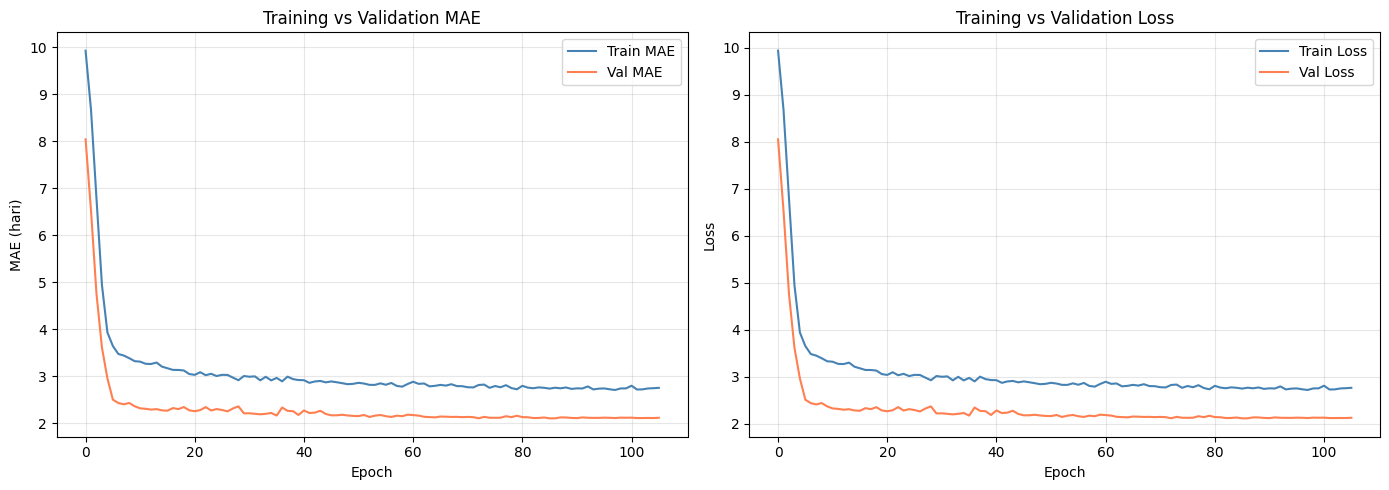

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAE
axes[0].plot(history.history['mae'], label='Train MAE', color='steelblue')
axes[0].plot(history.history['val_mae'], label='Val MAE', color='coral')
axes[0].set_title('Training vs Validation MAE')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MAE (hari)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Train Loss', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Val Loss', color='coral')
axes[1].set_title('Training vs Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model_output/training_history.png', dpi=150)
plt.show()

In [43]:
# Load model terbaik (dari checkpoint)
best_model = keras.models.load_model('model_output/best_model.keras')

# Prediksi (float)
y_pred_raw = best_model.predict(X_test, verbose=0).flatten()

# Clip ke >= 0 (sisa hari tidak mungkin negatif)
y_pred_float = np.clip(y_pred_raw, 0, None)

# Pembulatan hanya untuk tampilan / inference — TIDAK dipakai untuk menghitung metrik
y_pred_rounded = np.round(y_pred_float).astype(int)

# ── Metrik pada nilai float (lebih akurat) ──
mae  = mean_absolute_error(y_test, y_pred_float)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_float))
r2   = r2_score(y_test, y_pred_float)

print('=' * 40)
print('  EVALUASI TEST SET (nilai float)')
print('=' * 40)
print(f'  MAE  : {mae:.3f} hari')
print(f'  RMSE : {rmse:.3f} hari')
print(f'  R²   : {r2:.4f}')
print('=' * 40)

# ── Perbandingan aktual vs prediksi ──
results_df = pd.DataFrame({
    'Aktual (hari)': y_test,
    'Prediksi Float': y_pred_float.round(2),
    'Prediksi Bulat': y_pred_rounded,
    'Error': np.abs(y_test - y_pred_float).round(2)
})
results_df.head(20)

  EVALUASI TEST SET (nilai float)
  MAE  : 2.393 hari
  RMSE : 3.565 hari
  R²   : 0.8856


,Aktual (hari),Prediksi Float,Prediksi Bulat,Error
0,22.799999,17.030001,17,5.77
1,38.000000,28.860001,29,9.14
2,0.700000,0.620000,1,0.08
3,0.900000,4.030000,4,3.13
4,2.200000,1.310000,1,0.89
5,6.800000,8.490000,8,1.69
6,14.200000,11.050000,11,3.15
7,21.000000,16.730000,17,4.27
8,0.600000,0.620000,1,0.02
9,3.500000,1.800000,2,1.70


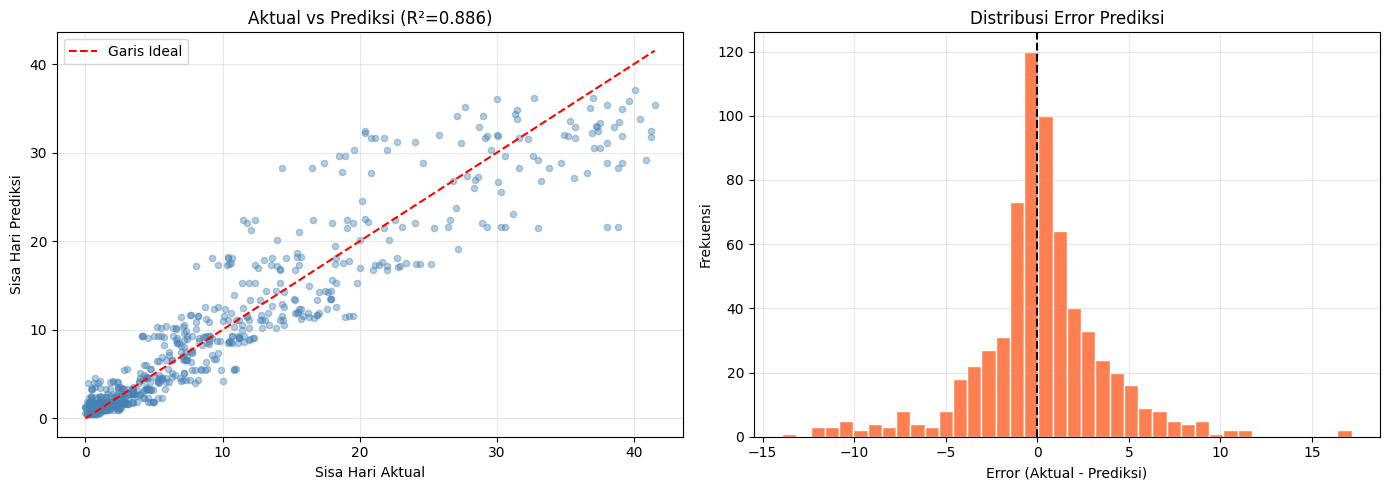

In [45]:
# ── Plot Aktual vs Prediksi ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_test, y_pred_float, alpha=0.4, color='steelblue', s=20)
max_val = max(y_test.max(), y_pred_float.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', label='Garis Ideal')
axes[0].set_xlabel('Sisa Hari Aktual')
axes[0].set_ylabel('Sisa Hari Prediksi')
axes[0].set_title(f'Aktual vs Prediksi (R²={r2:.3f})')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Distribusi error
errors = y_test - y_pred_float
axes[1].hist(errors, bins=40, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Error (Aktual - Prediksi)')
axes[1].set_ylabel('Frekuensi')
axes[1].set_title('Distribusi Error Prediksi')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model_output/evaluasi_prediksi.png', dpi=150)
plt.show()